In [2]:

# import library
from google.colab import files
uploaded = files.upload()
import pandas as pd
import matplotlib.pyplot as plt

Saving sales data-set.csv to sales data-set.csv


In [3]:

# load the data set
data = pd.read_csv("sales data-set.csv")
print(data.head())

   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  05/02/2010      24924.50      False
1      1     1  12/02/2010      46039.49       True
2      1     1  19/02/2010      41595.55      False
3      1     1  26/02/2010      19403.54      False
4      1     1  05/03/2010      21827.90      False


In [4]:

# get information of data set
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [5]:

# get the shape of data, number of row and column
data.shape

(421570, 5)

In [6]:

# get the null values
data.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0


In [8]:

# The day with the higest sales
Isholiday_sales = data.groupby(data["IsHoliday"]).sum()["Weekly_Sales"].sort_values(ascending=False)
print(Isholiday_sales)

IsHoliday
False    6.231919e+09
True     5.052996e+08
Name: Weekly_Sales, dtype: float64


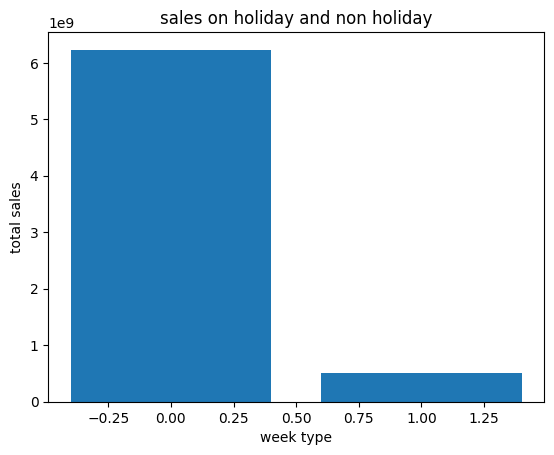

In [11]:


# visualization of the sales
plt.bar(Isholiday_sales.index, Isholiday_sales.values)
plt.ylabel('total sales')
plt.xlabel('week type')
plt.title('sales on holiday and non holiday')
plt.show()

In [13]:

holiday_data = data[data["IsHoliday"] == True]

print(holiday_data)

        Store  Dept        Date  Weekly_Sales  IsHoliday
1           1     1  12/02/2010      46039.49       True
31          1     1  10/09/2010      18194.74       True
42          1     1  26/11/2010      18820.29       True
47          1     1  31/12/2010      19124.58       True
53          1     1  11/02/2011      37887.17       True
...       ...   ...         ...           ...        ...
421510     45    98  09/09/2011       1092.66       True
421521     45    98  25/11/2011        794.62       True
421526     45    98  30/12/2011        553.21       True
421532     45    98  10/02/2012        770.86       True
421562     45    98  07/09/2012        352.44       True

[29661 rows x 5 columns]


In [15]:

#total holiday sales
holiday_sales = data[data["IsHoliday"] == True]["Weekly_Sales"].sum()

print(holiday_sales)

505299551.56


In [16]:

# holiday sales by department
holiday_sales_dept = data[data["IsHoliday"] == True].groupby("Dept")["Weekly_Sales"].sum()

print(holiday_sales_dept)

Dept
1      8867168.77
2     18991468.92
3      5481134.64
4     12005820.97
5     14347362.90
         ...     
95    29996233.40
96     5723180.51
97     6133824.50
98     3191644.19
99      119272.58
Name: Weekly_Sales, Length: 81, dtype: float64


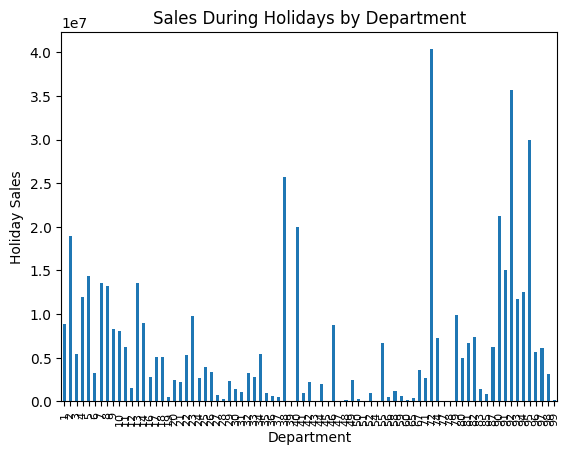

In [17]:

#Visualization
holiday_sales_dept.plot(kind="bar")
plt.xlabel("Department")
plt.ylabel("Holiday Sales")
plt.xticks(rotation='vertical', size=8)
plt.title("Sales During Holidays by Department")
plt.show()

In [18]:

# department with high holiday sales
top_holiday_sales_by_dept=holiday_sales_dept.sort_values(ascending=False)

In [19]:
top_holiday_sales_by_dept

,Weekly_Sales
Dept,
72,40313605.46
92,35695397.10
95,29996233.40
38,25682245.57
90,21209128.22
...,...
51,1711.58
47,250.93
78,169.76


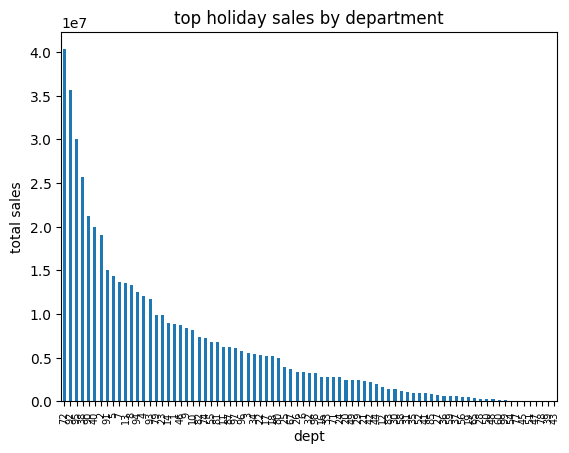

In [24]:
top_holiday_sales_by_dept.plot(kind="bar")
plt.xlabel('dept')
plt.ylabel('total sales')
plt.title('top holiday sales by department')
plt.xticks(rotation='vertical', size=7)
plt.show()

In [28]:

 #Comparison btn hiliday week sales and non holiday week sales
sales_compare = data.groupby("IsHoliday")["Weekly_Sales"].mean()

print(sales_compare)

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64


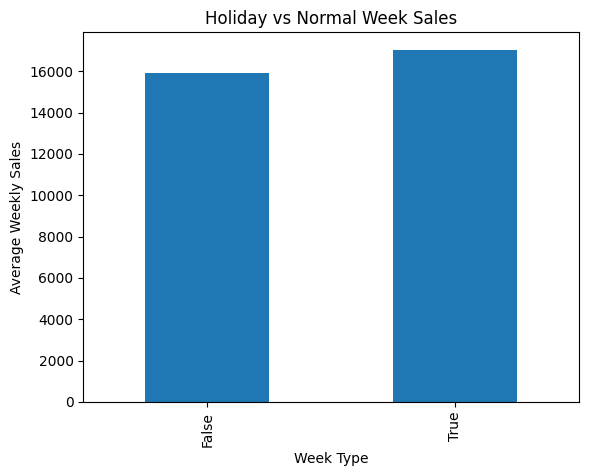

In [29]:

#visualization of the holiday and normal week sales
sales_compare.plot(kind="bar")
plt.xlabel("Week Type")
plt.ylabel("Average Weekly Sales")
plt.title("Holiday vs Normal Week Sales")
plt.show()

In [33]:

# convert the date inform of month_year
data["month_year"] = pd.to_datetime(data["Date"], format="%d/%m/%Y").dt.strftime("%y-%m")
data["month_year"]

,month_year
0,10-02
1,10-02
2,10-02
3,10-02
4,10-03
...,...
421565,12-09
421566,12-10
421567,12-10
421568,12-10


In [34]:

# the month with the highest sales
data.groupby(["month_year"]).sum()["Weekly_Sales"].sort_values(ascending=False)

,Weekly_Sales
month_year,
10-12,2.887605e+08
11-12,2.880781e+08
12-06,2.406103e+08
12-08,2.368508e+08
10-07,2.325801e+08
12-03,2.315097e+08
10-04,2.314124e+08
11-07,2.299114e+08
11-04,2.265265e+08


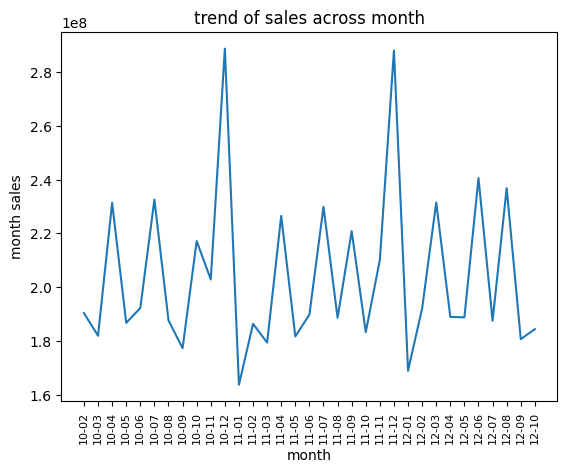

In [35]:

# the trend of sales
sales_trend = data.groupby(["month_year"]).sum()["Weekly_Sales"]
plt.plot(sales_trend.index, sales_trend.values)
plt.ylabel('month sales')
plt.xlabel('month')
plt.title('trend of sales across month')
plt.xticks(rotation='vertical', size=8)
plt.show()

In [13]:
mostsold_dept=data.groupby(["Dept"]).sum()["Weekly_Sales"].sort_values(ascending=False)
print(mostsold_dept)

Dept
92    4.839433e+08
95    4.493202e+08
38    3.931181e+08
72    3.057252e+08
90    2.910685e+08
          ...     
51    3.057283e+04
78    1.714710e+03
39    1.779800e+02
43    1.432000e+01
47   -4.962930e+03
Name: Weekly_Sales, Length: 81, dtype: float64


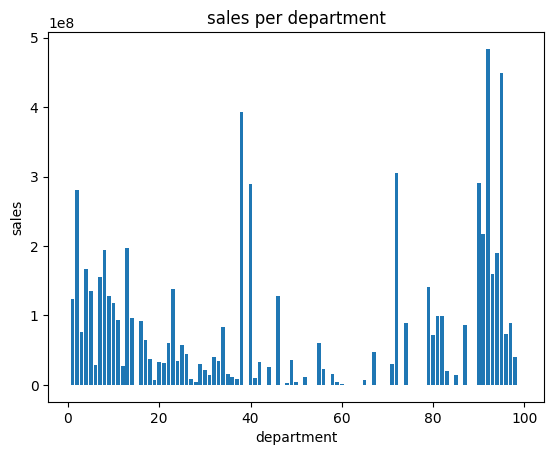

In [17]:
plt.bar(mostsold_dept.index, mostsold_dept.values)
plt.ylabel('sales')
plt.xlabel('department')
plt.title('sales per department')
plt.show()

In [33]:
data["Store"].max()

45

In [34]:
data["Store"].min()

1

In [36]:
data["Store"]

,Store
0,1
1,1
2,1
3,1
4,1
...,...
421565,45
421566,45
421567,45
421568,45


In [41]:

# top performing store by sales
top_store=data.groupby(["Store"]).sum()["Weekly_Sales"].sort_values(ascending=False)
print(top_store)

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
19    2.066349e+08
31    1.996139e+08
23    1.987506e+08
24    1.940160e+08
11    1.939628e+08
28    1.892637e+08
41    1.813419e+08
32    1.668192e+08
18    1.551147e+08
22    1.470756e+08
12    1.442872e+08
26    1.434164e+08
34    1.382498e+08
40    1.378703e+08
35    1.315207e+08
8     1.299512e+08
17    1.277821e+08
45    1.123953e+08
21    1.081179e+08
25    1.010612e+08
43    9.056544e+07
15    8.913368e+07
7     8.159828e+07
42    7.956575e+07
9     7.778922e+07
29    7.714155e+07
16    7.425243e+07
37    7.420274e+07
30    6.271689e+07
3     5.758674e+07
38    5.515963e+07
36    5.341221e+07
5     4.547569e+07
44    4.329309e+07
33    3.716022e+07
Name: Weekly_Sales, dtype: float64


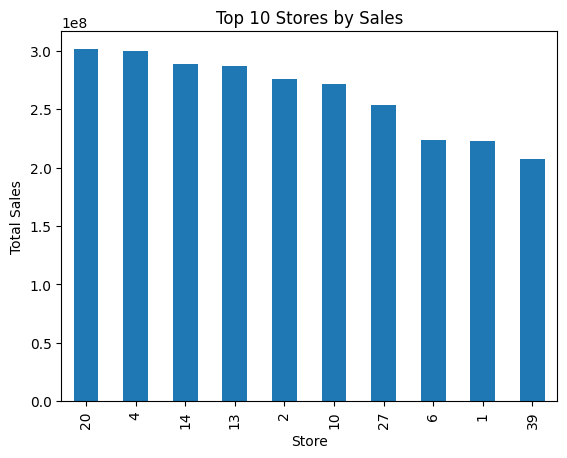

In [43]:
#visualization of the top 10
top_store.head(10).plot(kind="bar")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.title("Top 10 Stores by Sales")
plt.show()

In [48]:

#Store with high holiday sales
holiday_store_sales = data[data["IsHoliday"]==True].groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False)

print(holiday_store_sales.sort_values(ascending=False))

Store
20    22490350.81
4     22431026.24
14    21205829.98
10    21137559.49
13    21130438.06
2     20792669.00
27    18922992.78
6     16809079.27
1     16657476.56
19    15770467.34
39    15511274.80
31    15000260.30
28    14782446.05
24    14750982.51
23    14625422.94
11    14483944.85
41    13349478.56
32    12037840.83
18    11694221.61
12    11381404.20
22    10848746.56
35    10743484.57
26    10720468.49
34    10419780.89
40    10080340.75
17     9797969.71
8      9753308.60
45     8362937.13
21     8264913.09
25     7396768.42
15     7064060.18
7      6724002.65
43     6359462.78
29     6069578.89
9      5889508.21
42     5676941.58
16     5667336.46
37     5075250.50
3      4378110.50
30     4368593.07
38     3815098.78
36     3676406.30
5      3595016.07
44     2960356.01
33     2625945.19
Name: Weekly_Sales, dtype: float64


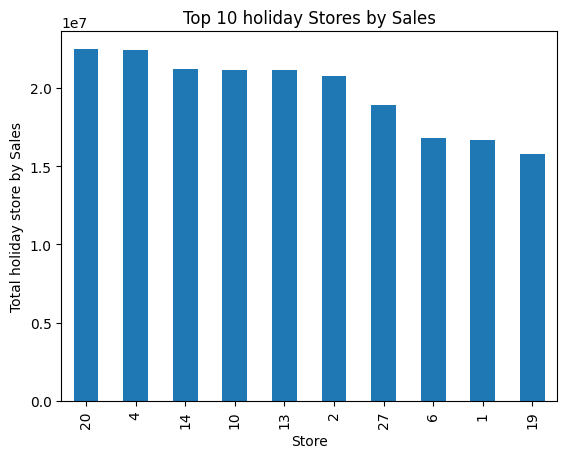

In [49]:
holiday_store_sales.head(10).plot(kind="bar")
plt.xlabel("Store")
plt.ylabel("Total holiday store by Sales")
plt.title("Top 10 holiday Stores by Sales")
plt.show()

In [50]:

#monthly sales for each store
store_trend = data.groupby(["month_year","Store"])["Weekly_Sales"].sum()

print(store_trend)

month_year  Store
10-02       1        6307344.10
            2        8264347.77
            3        1711198.23
            4        8299040.36
            5        1202728.00
                        ...    
12-10       41       5452445.75
            42       2261705.49
            43       2473507.39
            44       1360020.41
            45       2946326.39
Name: Weekly_Sales, Length: 1485, dtype: float64


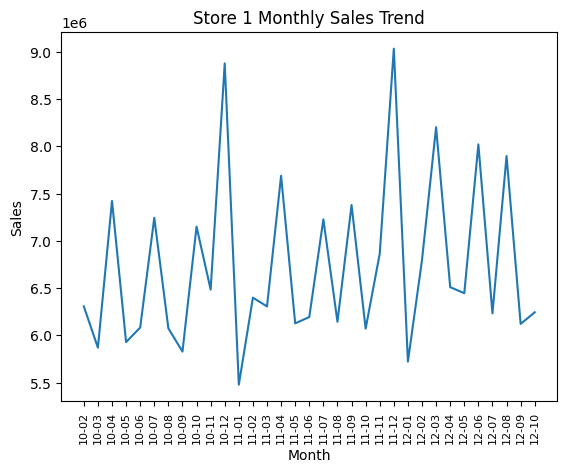

In [52]:

# trend in monthly sales in store 1
store1 = data[data["Store"] == 1].groupby("month_year")["Weekly_Sales"].sum()

plt.plot(store1.index, store1.values)
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation='vertical', size=8)
plt.title("Store 1 Monthly Sales Trend")
plt.show()

In [27]:

# department in store 20
store20 = data[data["Store"] == 20]
print(store20)

        Store  Dept        Date  Weekly_Sales  IsHoliday
187335     20     1  05/02/2010      46021.21      False
187336     20     1  12/02/2010      52734.17       True
187337     20     1  19/02/2010      55649.79      False
187338     20     1  26/02/2010      36805.42      False
187339     20     1  05/03/2010      41206.78      False
...       ...   ...         ...           ...        ...
197544     20    99  07/09/2012          0.67       True
197545     20    99  14/09/2012          0.05      False
197546     20    99  21/09/2012         29.91      False
197547     20    99  05/10/2012        660.00      False
197548     20    99  12/10/2012        200.00      False

[10214 rows x 5 columns]


In [28]:
dept_sales = store20.groupby("Dept")["Weekly_Sales"].sum().sort_values(ascending=False)
print(dept_sales)

Dept
92    23542625.04
95    21537795.62
38    15759345.93
90    13707777.99
72    13154550.44
         ...     
45         666.18
96         244.27
51         161.18
78          29.00
47        -378.58
Name: Weekly_Sales, Length: 78, dtype: float64


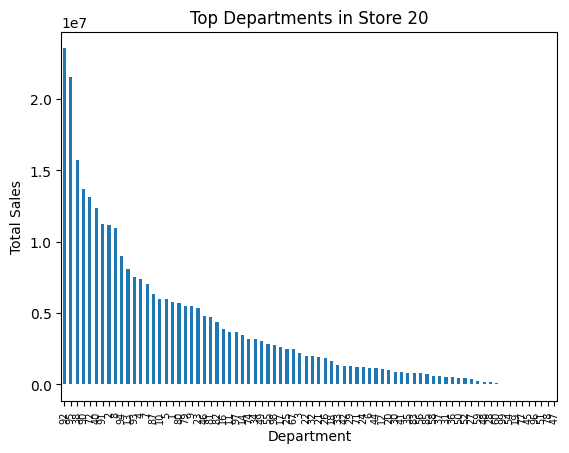

In [30]:

# department in store 20 wich generate high sales
dept_sales.plot(kind="bar")
plt.title("Top Departments in Store 20")
plt.xlabel("Department")
plt.ylabel("Total Sales")
plt.xticks(size=7)
plt.show()